# Data Preparation

**Kelompok G02:** 
- Inggried Amelia Deswanty - 18223035
- Muhammad Aqmar Fayyaz Zakaria - 18223043 
- Amudi Purba - 18223049
- Nadia Apsarini Baizal - 18223065
- Velicia Christina Gabriel - 18223085

In [ ]:
import textwrap
import os, re, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

In [53]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [54]:
DATA_DIR = Path("./Datasets")
df_raw   = pd.read_csv(DATA_DIR / "Resume.csv")               
df_cand  = pd.read_csv(DATA_DIR / "resume_dataset_1200.csv")  

print(f"Dataset 1 (Snehaan Bhawal):       {df_raw.shape[0]:>5} rows × {df_raw.shape[1]} cols")
print(f"Dataset 2 (Sayyed Faizan):        {df_cand.shape[0]:>5} rows × {df_cand.shape[1]} cols")

Dataset 1 (Snehaan Bhawal):        2484 rows × 4 cols
Dataset 2 (Sayyed Faizan):         1200 rows × 14 cols


## Data Understanding — Dataset 1

### Schema & sample

In [55]:
print("Columns:", df_raw.columns.tolist())
df_raw.head(3)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [56]:
print("dtypes:")
print(df_raw.dtypes)
print()
print("Memory footprint:", df_raw.memory_usage(deep=True).sum() / 1e6, "MB")
print()
print("Sample of `Resume_str` (first 600 chars):\n")
print(df_raw["Resume_str"].iloc[0][:600])

dtypes:
ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

Memory footprint: 90.40493 MB

Sample of `Resume_str` (first 600 chars):

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Ce


### Class distribution & imbalance

Number of categories: 24
Largest: INFORMATION-TECHNOLOGY = 120
Smallest: BPO = 22
Imbalance ratio (max/min): 5.5×



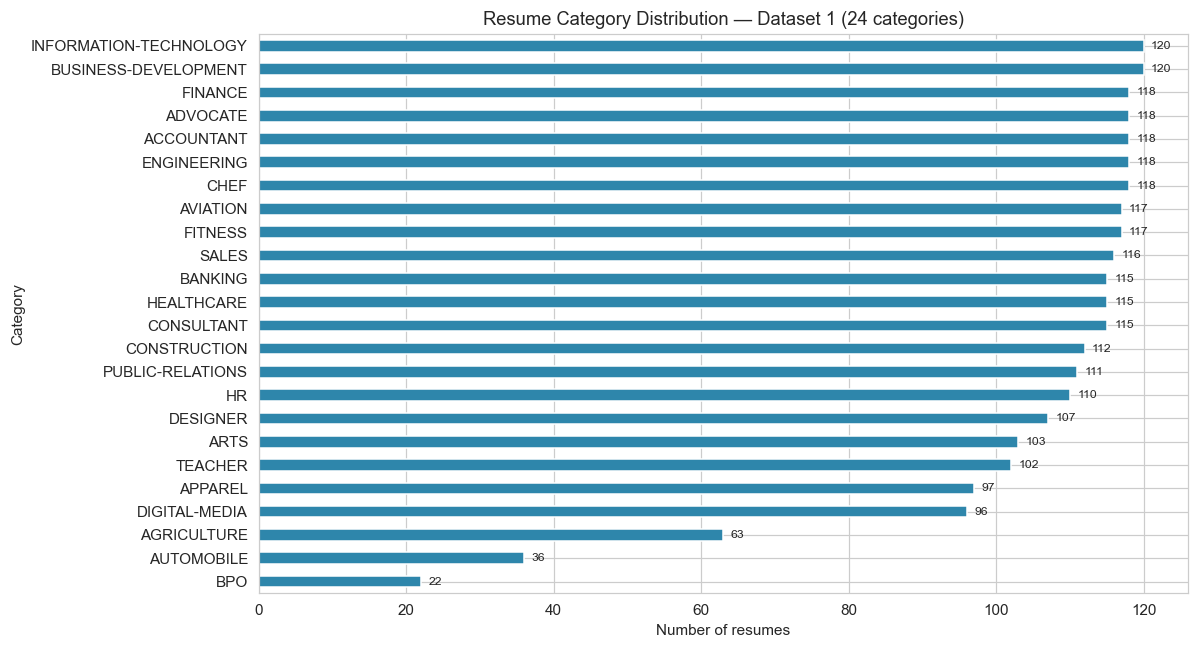

In [57]:
cat_counts = df_raw["Category"].value_counts()
print("Number of categories:", len(cat_counts))
print("Largest:", cat_counts.idxmax(), "=", int(cat_counts.max()))
print("Smallest:", cat_counts.idxmin(), "=", int(cat_counts.min()))
print(f"Imbalance ratio (max/min): {cat_counts.max() / cat_counts.min():.1f}×\n")

fig, ax = plt.subplots(figsize=(11, 6))
cat_counts.plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title(f"Resume Category Distribution — Dataset 1 ({len(cat_counts)} categories)")
ax.set_xlabel("Number of resumes"); ax.invert_yaxis()
for i, v in enumerate(cat_counts.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=8)
plt.tight_layout(); plt.show()

### Resume length distribution & text quality

In [58]:
df_raw["len_chars"] = df_raw["Resume_str"].str.len()
df_raw["len_words"] = df_raw["Resume_str"].str.split().str.len()

print(df_raw[["len_chars", "len_words"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(1))
print(f"\nResumes shorter than 200 chars: {(df_raw['len_chars'] < 200).sum()} (likely truncated/parser failures)")
print(f"Resumes longer than 30k chars:  {(df_raw['len_chars'] > 30000).sum()} (likely concatenated multi-doc)")

       len_chars  len_words
count     2484.0     2484.0
mean      6302.0      811.3
std       2777.2      371.0
min         21.0        0.0
5%        2439.6      302.2
25%       5163.8      651.0
50%       5889.0      757.0
75%       7228.2      933.0
95%      10795.2     1398.7
max      40009.0     5190.0

Resumes shorter than 200 chars: 1 (likely truncated/parser failures)
Resumes longer than 30k chars:  3 (likely concatenated multi-doc)


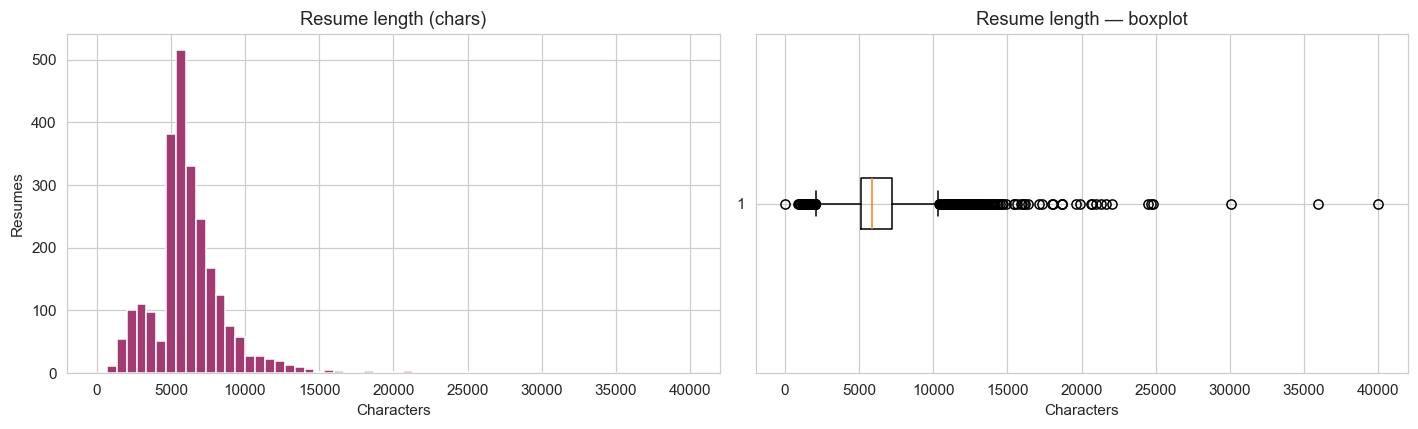

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].hist(df_raw["len_chars"], bins=60, color="#A23B72", edgecolor="white")
axs[0].set_xlabel("Characters"); axs[0].set_ylabel("Resumes"); axs[0].set_title("Resume length (chars)")
axs[1].boxplot(df_raw["len_chars"], vert=False)
axs[1].set_xlabel("Characters"); axs[1].set_title("Resume length — boxplot")
plt.tight_layout(); plt.show()

### Vocabulary, skill frequency & semantic-similarity necessity

In [ ]:
vec_quick = CountVectorizer(stop_words="english", min_df=5, max_df=0.95, token_pattern=r"[A-Za-z][A-Za-z+#\-]{2,}")
X_quick = vec_quick.fit_transform(df_raw["Resume_str"].astype(str).str.lower())
vocab_size = X_quick.shape[1]
total_tokens = X_quick.sum()
type_token_ratio = vocab_size / total_tokens
print(f"Distinct lowercase types (min_df=5):  {vocab_size:>7,}")
print(f"Total token occurrences:              {total_tokens:>7,}")
print(f"Type/token ratio:                     {type_token_ratio:.4f}")
print()
top_terms = pd.Series(np.asarray(X_quick.sum(axis=0)).ravel(),
                      index=vec_quick.get_feature_names_out()).sort_values(ascending=False)
print("Top 20 terms across all 2,484 resumes:")
print(top_terms.head(20))

Distinct lowercase types (min_df=5):   10,829
Total token occurrences:              1,272,030
Type/token ratio:                     0.0085

Top 20 terms across all 2,484 resumes:
management      12117
sales            8223
customer         7795
business         7779
new              6361
service          6056
team             5923
development      5715
training         5609
project          5331
work             4719
manager          4514
information      4497
marketing        4466
financial        4221
office           4139
support          4116
including        4040
staff            3942
professional     3857
dtype: int64


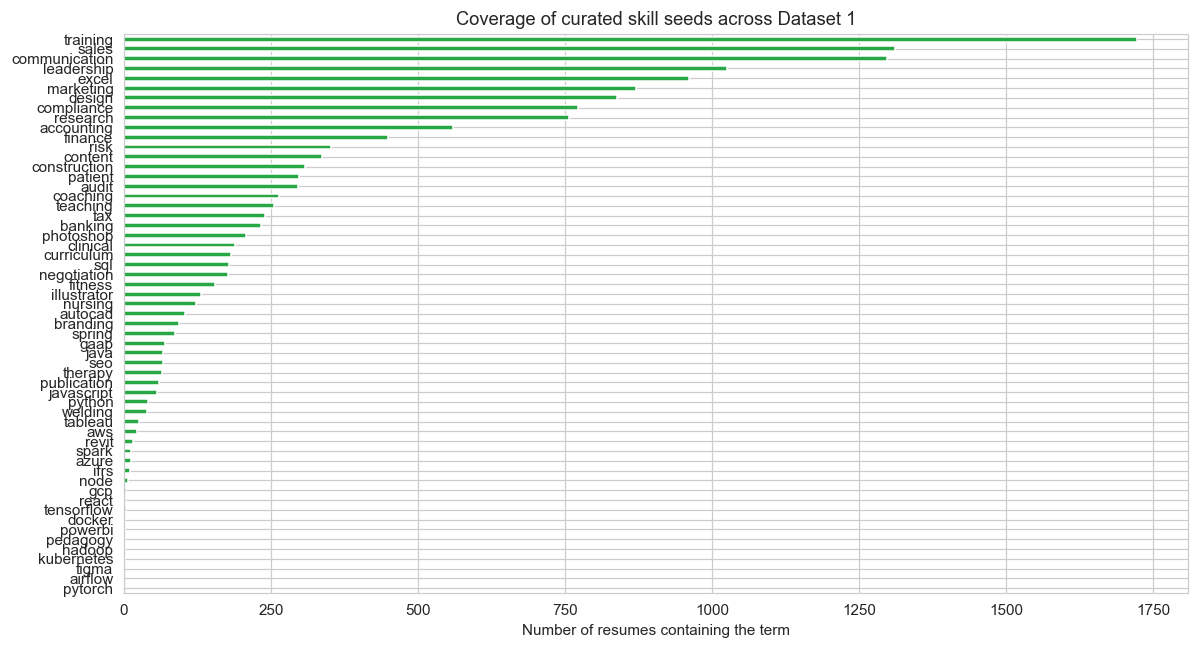

In [ ]:
SKILL_SEEDS = [
    "python","sql","excel","tableau","powerbi","aws","azure","gcp","docker","kubernetes",
    "javascript","react","node","java","spring","tensorflow","pytorch","spark","hadoop","airflow",
    "communication","leadership","negotiation","sales","marketing","seo","content","branding",
    "accounting","audit","finance","banking","compliance","risk","gaap","ifrs","tax",
    "nursing","clinical","patient","therapy","fitness","training","coaching",
    "design","figma","photoshop","illustrator","autocad","revit","construction","welding",
    "teaching","curriculum","pedagogy","research","publication"
]
text_concat = df_raw["Resume_str"].astype(str).str.lower()
skill_freq = pd.Series({s: text_concat.str.contains(rf"\b{s}\b", regex=True).sum() for s in SKILL_SEEDS})
skill_freq = skill_freq.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 6))
skill_freq.plot(kind="barh", ax=ax, color="#28a745")
ax.set_title("Coverage of curated skill seeds across Dataset 1")
ax.set_xlabel("Number of resumes containing the term")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Data Understanding — Dataset 2

In [62]:
print(df_cand.dtypes)
df_cand.head(3)

Name                      object
Age                        int64
Gender                    object
Education_Level           object
Field_of_Study            object
Degrees                   object
Institute_Name            object
Graduation_Year            int64
Experience_Years           int64
Current_Job_Title         object
Previous_Job_Titles       object
Skills                    object
Certifications            object
Target_Job_Description    object
dtype: object


,Name,Age,Gender,Education_Level,Field_of_Study,Degrees,Institute_Name,Graduation_Year,Experience_Years,Current_Job_Title,Previous_Job_Titles,Skills,Certifications,Target_Job_Description
0,Akash Pillai,30,Non-Binary,Master's,Cybersecurity,Master's in Cybersecurity,University of Pennsylvania,2025,0,NaN,NaN,"Node.js, JavaScript, Deep Learning, Statistics...",Google Cloud Professional,Seeking a challenging role as a Software Devel...
1,Charlotte Taylor,27,Non-Binary,Bachelor's,Electronics Engineering,Bachelor's in Electronics Engineering,Pune University,2019,5,Cybersecurity Engineer,NaN,"Spark, Kubernetes, Terraform, Natural Language...",TensorFlow Developer Certificate,Targeting a Cybersecurity Engineer position to...
2,James Zhou,45,Male,Bachelor's,Computer Science,Bachelor's in Computer Science,Amity University,2023,2,Prompt Engineer,NaN,"Data Analysis, Node.js, Machine Learning, Linu...","Microsoft Azure Fundamentals, Cisco Certified ...",Targeting a Prompt Engineer position to utiliz...


In [63]:
print("Missing values per column:")
miss = df_cand.isna().sum().sort_values(ascending=False)
print(miss[miss > 0])
print()
print(f"`Current_Job_Title` missing rate:    {miss.get('Current_Job_Title',0)/len(df_cand):.1%}")
print(f"`Previous_Job_Titles` missing rate:  {miss.get('Previous_Job_Titles',0)/len(df_cand):.1%}")
print(f"`Certifications` missing rate:       {miss.get('Certifications',0)/len(df_cand):.1%}")

Missing values per column:
Previous_Job_Titles    914
Current_Job_Title      441
Certifications         319
dtype: int64

`Current_Job_Title` missing rate:    36.8%
`Previous_Job_Titles` missing rate:  76.2%
`Certifications` missing rate:       26.6%


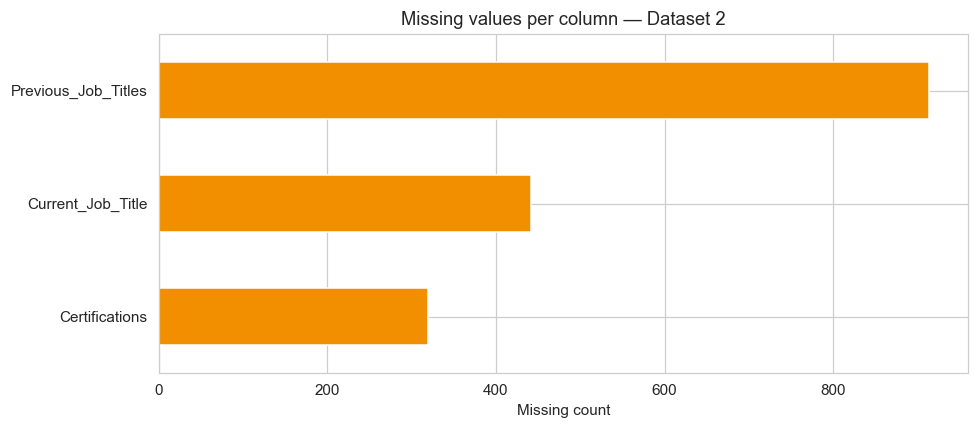

In [64]:
fig, ax = plt.subplots(figsize=(9,4))
miss[miss>0].sort_values().plot(kind="barh", ax=ax, color="#F18F01")
ax.set_title("Missing values per column — Dataset 2"); ax.set_xlabel("Missing count")
plt.tight_layout(); plt.show()

### Experience years

count    1200.000000
mean        2.258333
std         2.505693
min         0.000000
25%         0.000000
50%         1.000000
75%         4.000000
max        10.000000
Name: Experience_Years, dtype: float64


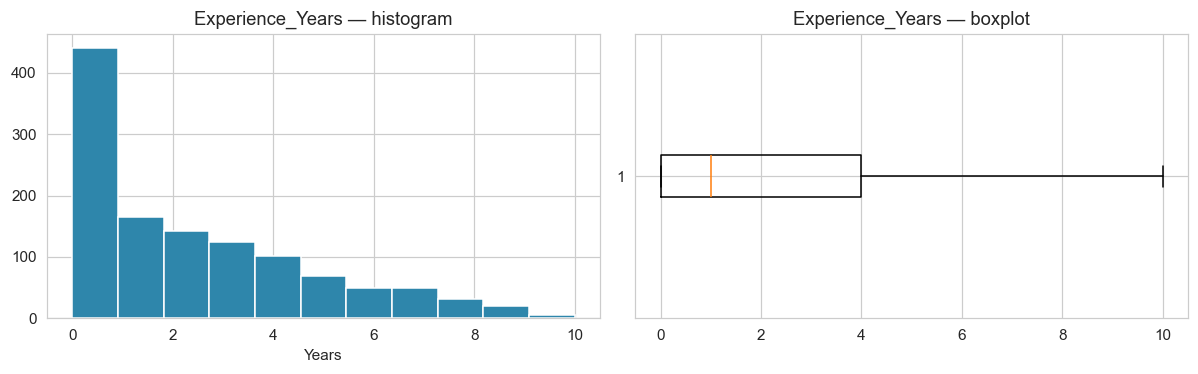

Years distribution (binned):
Experience_Years
fresh          441
junior         307
mid            296
senior         156
very_senior      0
Name: count, dtype: int64


In [65]:
print(df_cand["Experience_Years"].describe())
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
axs[0].hist(df_cand["Experience_Years"], bins=11, color="#2E86AB", edgecolor="white")
axs[0].set_title("Experience_Years — histogram"); axs[0].set_xlabel("Years")
axs[1].boxplot(df_cand["Experience_Years"], vert=False)
axs[1].set_title("Experience_Years — boxplot")
plt.tight_layout(); plt.show()
print("Years distribution (binned):")
print(pd.cut(df_cand["Experience_Years"], bins=[-0.1,0,2,5,10,99],
             labels=["fresh","junior","mid","senior","very_senior"]).value_counts().sort_index())

### Skill text richness

In [66]:
def parse_skills(s):
    if pd.isna(s): return []
    return [x.strip().lower() for x in re.split(r"[;,]", s) if x.strip()]

df_cand["skills_list"]   = df_cand["Skills"].apply(parse_skills)
df_cand["n_skills"]      = df_cand["skills_list"].str.len()
print(df_cand["n_skills"].describe().round(2))
all_skills = Counter([s for lst in df_cand["skills_list"] for s in lst])
print(f"\nDistinct skills (case-folded): {len(all_skills)}")
print("\nTop 25 skills:")
for k,v in all_skills.most_common(25):
    print(f"  {v:>4}  {k}")

count    1200.00
mean        6.01
std         1.42
min         4.00
25%         5.00
50%         6.00
75%         7.00
max         8.00
Name: n_skills, dtype: float64

Distinct skills (case-folded): 71

Top 25 skills:
   193  data analysis
   135  sql
   129  tensorflow
   128  linux
   126  terraform
   125  statistics
   123  aws
   120  mongodb
   118  natural language processing
   117  blockchain
   116  graphql
   115  kubernetes
   115  jenkins
   115  network security
   115  solidity
   113  pytorch
   113  penetration testing
   112  javascript
   111  ci/cd
   109  rest apis
   109  azure
   109  scrum
   108  python
   108  microservices
   108  patient care


### The `Target_Job_Description` problem — *the* sufficiency gap

In [67]:
# Empirical test: is `Target_Job_Description` actually employer-side, or candidate-side?
emp_keywords  = ["responsibilities","qualifications","we are","looking for","required skills",
                 "must have","we offer","the candidate will","you will","join our team"]
cand_keywords = ["seeking","aspiring","looking for a","utilize my","apply my","targeting",
                 "to leverage my","an opportunity","my expertise","seeking a"]

def count_hits(text, kws):
    t = str(text).lower()
    return sum(1 for k in kws if k in t)

emp_hits  = df_cand["Target_Job_Description"].apply(lambda t: count_hits(t, emp_keywords))
cand_hits = df_cand["Target_Job_Description"].apply(lambda t: count_hits(t, cand_keywords))
print(f"Rows containing employer-side phrasing:    {(emp_hits  > 0).sum():>5} / {len(df_cand)}")
print(f"Rows containing candidate-side phrasing:   {(cand_hits > 0).sum():>5} / {len(df_cand)}")
print()
print("Three random samples of `Target_Job_Description`:\n")
for i in [0, 100, 999]:
    print(f"[{i}]", df_cand['Target_Job_Description'].iloc[i])
    print()

Rows containing employer-side phrasing:      389 / 1200
Rows containing candidate-side phrasing:    1200 / 1200

Three random samples of `Target_Job_Description`:

[0] Seeking a challenging role as a Software Developer where I can apply my skills and knowledge to contribute to organizational success and professional growth.

[100] Seeking a challenging role as a Site Reliability Engineer where I can apply my skills and knowledge to contribute to organizational success and professional growth.

[999] Targeting a Brand Manager position to utilize my educational background and experience to drive results and achieve career objectives.



## Data Preparation — Dataset 1

### Cleaning pipeline

In [ ]:
DATE_RE = re.compile(r"\b(jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
                     r"(uary|ruary|ch|il|e|y|ust|tember|ober|ember)?\b")

def clean_resume(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"<[^>]+>",         " ", s)              
    s = re.sub(r"\S+@\S+",         " ", s)              
    s = re.sub(r"http\S+|www\.\S+", " ", s)             
    s = re.sub(r"\b\d{7,}\b",      " ", s)              
    s = DATE_RE.sub(               " ", s)             
    s = re.sub(r"\d+",             " ", s)               
    s = re.sub(r"[^\w\s+#\.]",     " ", s)               
    s = re.sub(r"\s+",             " ", s).strip()       
    return s

df_raw["resume_clean"] = df_raw["Resume_str"].apply(clean_resume)

i = 0
print("BEFORE (first 350 chars):\n", df_raw["Resume_str"].iloc[i][:350])
print("\nAFTER  (first 350 chars):\n", df_raw["resume_clean"].iloc[i][:350])

BEFORE (first 350 chars):
          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights    

AFTER  (first 350 chars):
 hr administrator marketing associate hr administrator summary dedicated customer service manager with + years of experience in hospitality and customer service management. respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service. highlights focused on customer satisfaction team m


### Duplicates & length-based filtering

In [ ]:
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset="resume_clean").reset_index(drop=True)
after = len(df_raw)
print(f"Removed {before-after} exact duplicates after cleaning ({before} → {after}).")

lo, hi = 150, df_raw["resume_clean"].str.len().quantile(0.995)
mask = df_raw["resume_clean"].str.len().between(lo, hi)
print(f"Length filter [{lo}, {hi:.0f}] keeps {mask.sum()} / {len(df_raw)} rows")
df_raw = df_raw[mask].reset_index(drop=True)

Removed 2 exact duplicates after cleaning (2484 → 2482).
Length filter [150, 17793] keeps 2468 / 2482 rows


### Building the business-family taxonomy

In [70]:
FAMILY_MAP_4 = {
    # TECH & ENGINEERING
    "INFORMATION-TECHNOLOGY":"TECH","ENGINEERING":"TECH","AVIATION":"TECH",
    "AUTOMOBILE":"TECH","CONSTRUCTION":"TECH","AGRICULTURE":"TECH",
    # BUSINESS / FINANCE / SALES / MARKETING / HR / LEGAL
    "FINANCE":"BUSINESS","BANKING":"BUSINESS","ACCOUNTANT":"BUSINESS",
    "CONSULTANT":"BUSINESS","SALES":"BUSINESS","BUSINESS-DEVELOPMENT":"BUSINESS",
    "PUBLIC-RELATIONS":"BUSINESS","DIGITAL-MEDIA":"BUSINESS",
    "HR":"BUSINESS","ADVOCATE":"BUSINESS",
    # CREATIVE
    "DESIGNER":"CREATIVE","ARTS":"CREATIVE","APPAREL":"CREATIVE",
    # SERVICES (healthcare, fitness, hospitality, BPO, education)
    "HEALTHCARE":"SERVICES","FITNESS":"SERVICES","CHEF":"SERVICES",
    "BPO":"SERVICES","TEACHER":"SERVICES",
}
df_raw["Family"] = df_raw["Category"].map(FAMILY_MAP_4)
print("4-family distribution:")
print(df_raw["Family"].value_counts())

4-family distribution:
Family
BUSINESS    1128
TECH         561
SERVICES     472
CREATIVE     307
Name: count, dtype: int64


## Data Preparation — Dataset 2 + Integration to Schema
### Cleaning structured fields

In [ ]:
def normalise_title(t):
    if pd.isna(t): return None
    t = str(t).strip().lower()
    t = re.sub(r"\s+", " ", t)
    return t or None

SKILL_ALIASES = {
    "ml":"machine learning", "nlp":"natural language processing",
    "dl":"deep learning",    "cv":"computer vision",
    "k8s":"kubernetes",      "tf":"tensorflow",
    "js":"javascript",       "py":"python",
    "ai":"artificial intelligence",
    "rdbms":"sql",           "ms sql":"sql",          "mssql":"sql",
    "gcp":"google cloud",    "aws":"amazon web services",
    "spring boot":"spring",  "node.js":"node",
}

def canonical_skill(s):
    s = s.strip().lower()
    return SKILL_ALIASES.get(s, s)

df_cand["current_title_norm"]   = df_cand["Current_Job_Title"].apply(normalise_title)
df_cand["previous_titles_norm"] = df_cand["Previous_Job_Titles"].apply(normalise_title)
df_cand["skills_canonical"]     = df_cand["skills_list"].apply(
    lambda lst: sorted({canonical_skill(s) for s in lst}))

# Missingness as informative feature (Section 4 insight)
df_cand["is_fresh_graduate"]    = df_cand["current_title_norm"].isna().astype(int)
df_cand["has_certification"]    = df_cand["Certifications"].notna().astype(int)
df_cand["has_prev_role"]        = df_cand["previous_titles_norm"].notna().astype(int)

EDU_LEVEL = {"High School":1,"Associate's":2,"Bachelor's":3,"Master's":4,"PhD":5,"Doctorate":5}
df_cand["edu_level_ord"] = df_cand["Education_Level"].map(EDU_LEVEL).fillna(0).astype(int)

print(df_cand[["is_fresh_graduate","has_certification","has_prev_role","edu_level_ord"]].head())

   is_fresh_graduate  has_certification  has_prev_role  edu_level_ord
0                  1                  1              0              4
1                  0                  1              0              3
2                  0                  1              0              3
3                  0                  0              0              4
4                  0                  0              0              4


### Building a candidate-profile text (a unified surface for embedding & matching)

In [72]:
def build_candidate_profile(row):
    parts = []
    if row["current_title_norm"]:
        parts.append(f"Current role: {row['current_title_norm']}.")
    if row["previous_titles_norm"]:
        parts.append(f"Previous roles: {row['previous_titles_norm']}.")
    if row["skills_canonical"]:
        parts.append("Skills: " + ", ".join(row["skills_canonical"]) + ".")
    parts.append(f"Education: {row['Education_Level']} in {row['Field_of_Study']}.")
    parts.append(f"Experience: {row['Experience_Years']} years.")
    if pd.notna(row["Certifications"]):
        parts.append(f"Certifications: {row['Certifications']}.")
    return " ".join(parts)

df_cand["candidate_profile_text"] = df_cand.apply(build_candidate_profile, axis=1)
print(df_cand["candidate_profile_text"].iloc[3])

Current role: ai engineer. Skills: blockchain, docker, kubernetes, spark. Education: Master's in Information Technology. Experience: 2 years.


### Closing the Job Description gap

In [ ]:
TITLE_TO_FAMILY = {
    "software developer":"TECH","backend developer":"TECH","frontend developer":"TECH",
    "full stack developer":"TECH","fullstack developer":"TECH",
    "machine learning engineer":"TECH","data scientist":"TECH","data engineer":"TECH",
    "data analyst":"TECH","cloud engineer":"TECH","devops engineer":"TECH","site reliability engineer":"TECH",
    "cybersecurity engineer":"TECH","security engineer":"TECH",
    "blockchain engineer":"TECH","quantum computing specialist":"TECH",
    "prompt engineer":"TECH","ai engineer":"TECH","ai researcher":"TECH",
    "robotics engineer":"TECH","embedded engineer":"TECH","hardware engineer":"TECH",
    "network engineer":"TECH","mobile developer":"TECH","ios developer":"TECH","android developer":"TECH",
    "qa engineer":"TECH","test automation engineer":"TECH","game developer":"TECH",
    "project manager":"BUSINESS","product manager":"BUSINESS","scrum master":"BUSINESS",
    "business analyst":"BUSINESS","financial analyst":"BUSINESS","marketing manager":"BUSINESS",
    "sales manager":"BUSINESS","operations manager":"BUSINESS","hr manager":"BUSINESS","recruiter":"BUSINESS",
    "ux designer":"CREATIVE","ui designer":"CREATIVE","ux/ui designer":"CREATIVE","graphic designer":"CREATIVE",
    "content strategist":"CREATIVE",
    "technical writer":"SERVICES","customer success manager":"SERVICES","support engineer":"SERVICES",
}

title_skill_freq = {}
for _, r in df_cand.iterrows():
    t = r["current_title_norm"]
    if not t: continue
    bag = title_skill_freq.setdefault(t, Counter())
    bag.update(r["skills_canonical"])

JD_TEMPLATE = (
    "Position: {title}. We are seeking a {title} to join our team. "
    "Required skills: {required}. Nice to have: {nice}. "
    "The ideal candidate will have hands-on experience with {required_short} "
    "and a strong background in {field}. Responsibilities include applying "
    "{required_short} to deliver high-impact business outcomes. Qualifications: "
    "Bachelor's degree or higher in a relevant field; demonstrated proficiency "
    "in {required_short}."
)

def build_jd(title, skill_counter):
    most = [s for s,_ in skill_counter.most_common(8)]
    required = most[:5]
    nice     = most[5:]
    field    = "Computer Science / Engineering" if TITLE_TO_FAMILY.get(title) == "TECH" \
               else ("Business / Management"      if TITLE_TO_FAMILY.get(title) == "BUSINESS" \
               else  ("Design / Arts"              if TITLE_TO_FAMILY.get(title) == "CREATIVE" \
               else   "Services / Operations"))
    return JD_TEMPLATE.format(
        title=title.title(),
        required=", ".join(required) if required else "general role-relevant skills",
        nice=", ".join(nice) if nice else "additional certifications",
        required_short=", ".join(required[:3]) if required else "core competencies",
        field=field,
    )

jd_rows = []
for title, bag in title_skill_freq.items():
    fam = TITLE_TO_FAMILY.get(title, "BUSINESS")  # default
    jd_rows.append({
        "title": title,
        "family": fam,
        "n_observed_candidates": sum(bag.values()),
        "top_skills": ", ".join([s for s,_ in bag.most_common(5)]),
        "jd_text": build_jd(title, bag),
    })
jd_bank = pd.DataFrame(jd_rows).sort_values("n_observed_candidates", ascending=False)
print(f"JD bank size: {len(jd_bank)} synthetic, role-grounded job descriptions")
print()
print("Sample JD:\n")
print(jd_bank.iloc[0]["jd_text"])

JD bank size: 45 synthetic, role-grounded job descriptions

Sample JD:

Position: Prompt Engineer. We are seeking a Prompt Engineer to join our team. Required skills: ansible, pytorch, network security, computer vision, jenkins. Nice to have: linux, rest apis, graphql. The ideal candidate will have hands-on experience with ansible, pytorch, network security and a strong background in Computer Science / Engineering. Responsibilities include applying ansible, pytorch, network security to deliver high-impact business outcomes. Qualifications: Bachelor's degree or higher in a relevant field; demonstrated proficiency in ansible, pytorch, network security.


### Saving the prepared, integrated artefacts

In [ ]:
out_dir = Path(".")

clf_df = df_raw[["ID", "Category", "Family", "resume_clean"]].copy()
clf_df.to_csv(out_dir / "prepared_classification.csv", index=False)

cand_df = df_cand[["Name","Age","Gender","Education_Level","Field_of_Study",
                   "Experience_Years","current_title_norm","previous_titles_norm",
                   "skills_canonical","Certifications","is_fresh_graduate",
                   "has_certification","has_prev_role","edu_level_ord",
                   "candidate_profile_text"]].copy()
cand_df["skills_canonical"] = cand_df["skills_canonical"].apply(json.dumps)
cand_df.to_csv(out_dir / "prepared_candidates.csv", index=False)

jd_bank.to_csv(out_dir / "prepared_jd_bank.csv", index=False)

print("Saved:")
for f in ["prepared_classification.csv","prepared_candidates.csv","prepared_jd_bank.csv"]:
    p = out_dir / f
    print(f"  {f:<32}  {p.stat().st_size/1024:>8.1f} KB")

Saved:
  prepared_classification.csv        13494.0 KB
  prepared_candidates.csv              556.7 KB
  prepared_jd_bank.csv                  31.5 KB


## Feature Engineering


In [ ]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b: return 0.0
    return len(a & b) / max(len(a | b), 1)

def jd_skill_set(jd_row):
    raw = jd_row["top_skills"].split(",") if isinstance(jd_row["top_skills"], str) else []
    return {s.strip().lower() for s in raw if s.strip()}

matching_corpus = pd.concat(
    [df_cand["candidate_profile_text"], jd_bank["jd_text"]], ignore_index=True
)
m_vec = TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                        min_df=2, sublinear_tf=True, stop_words="english")
m_vec.fit(matching_corpus)
cand_mat = m_vec.transform(df_cand["candidate_profile_text"])
jd_mat   = m_vec.transform(jd_bank["jd_text"])
print(f"Candidate matrix: {cand_mat.shape}    JD matrix: {jd_mat.shape}")

Candidate matrix: (1200, 1854)    JD matrix: (45, 1854)


In [ ]:
sample = df_cand.head(5).reset_index(drop=True)
sample_mat = m_vec.transform(sample["candidate_profile_text"])
cos = cosine_similarity(sample_mat, jd_mat)

for i, row in sample.iterrows():
    skills_set = set(row["skills_canonical"])
    sims = []
    for j, jd_row in jd_bank.reset_index(drop=True).iterrows():
        jac = jaccard(skills_set, jd_skill_set(jd_row))
        sims.append((jd_row["title"], cos[i, j], jac))
    sims.sort(key=lambda x: (x[1] * 0.5 + x[2] * 0.5), reverse=True)
    print(f"\nCandidate: {row['Name']} — current: {row['current_title_norm']} — skills: {row['skills_canonical']}")
    print("  Top 3 JD matches (combined score = 0.5 cosine + 0.5 jaccard):")
    for t, c, j in sims[:3]:
        print(f"    {t:<30}  cosine={c:.3f}   jaccard={j:.3f}")


Candidate: Akash Pillai — current: None — skills: ['deep learning', 'javascript', 'node', 'sql', 'statistics']
  Top 3 JD matches (combined score = 0.5 cosine + 0.5 jaccard):
    big data engineer               cosine=0.064   jaccard=0.250
    quantum computing specialist    cosine=0.050   jaccard=0.250
    cloud architect                 cosine=0.052   jaccard=0.111

Candidate: Charlotte Taylor — current: cybersecurity engineer — skills: ['kubernetes', 'natural language processing', 'spark', 'terraform']
  Top 3 JD matches (combined score = 0.5 cosine + 0.5 jaccard):
    cybersecurity engineer          cosine=0.296   jaccard=0.500
    software developer              cosine=0.180   jaccard=0.125
    site reliability engineer       cosine=0.149   jaccard=0.125

Candidate: James Zhou — current: prompt engineer — skills: ['data analysis', 'jenkins', 'linux', 'machine learning', 'network security', 'node', 'rest apis']
  Top 3 JD matches (combined score = 0.5 cosine + 0.5 jaccard):
    pr